# LFP

## Loading data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import neo
from scipy.signal import spectrogram
from neo.io import NixIO
import viziphant
import elephant
import quantities as pq
%matplotlib inline
import sys
sys.path
from source import utils

In [3]:
with NixIO("../data/rat_retreat_meta_1kHz.nix", mode="ro") as io:
    block = io.read_block()

seg = block.segments[0]


## Applying bandpass filter

In [4]:
signals = seg.analogsignals[0]

In [5]:
fs = signals.sampling_rate

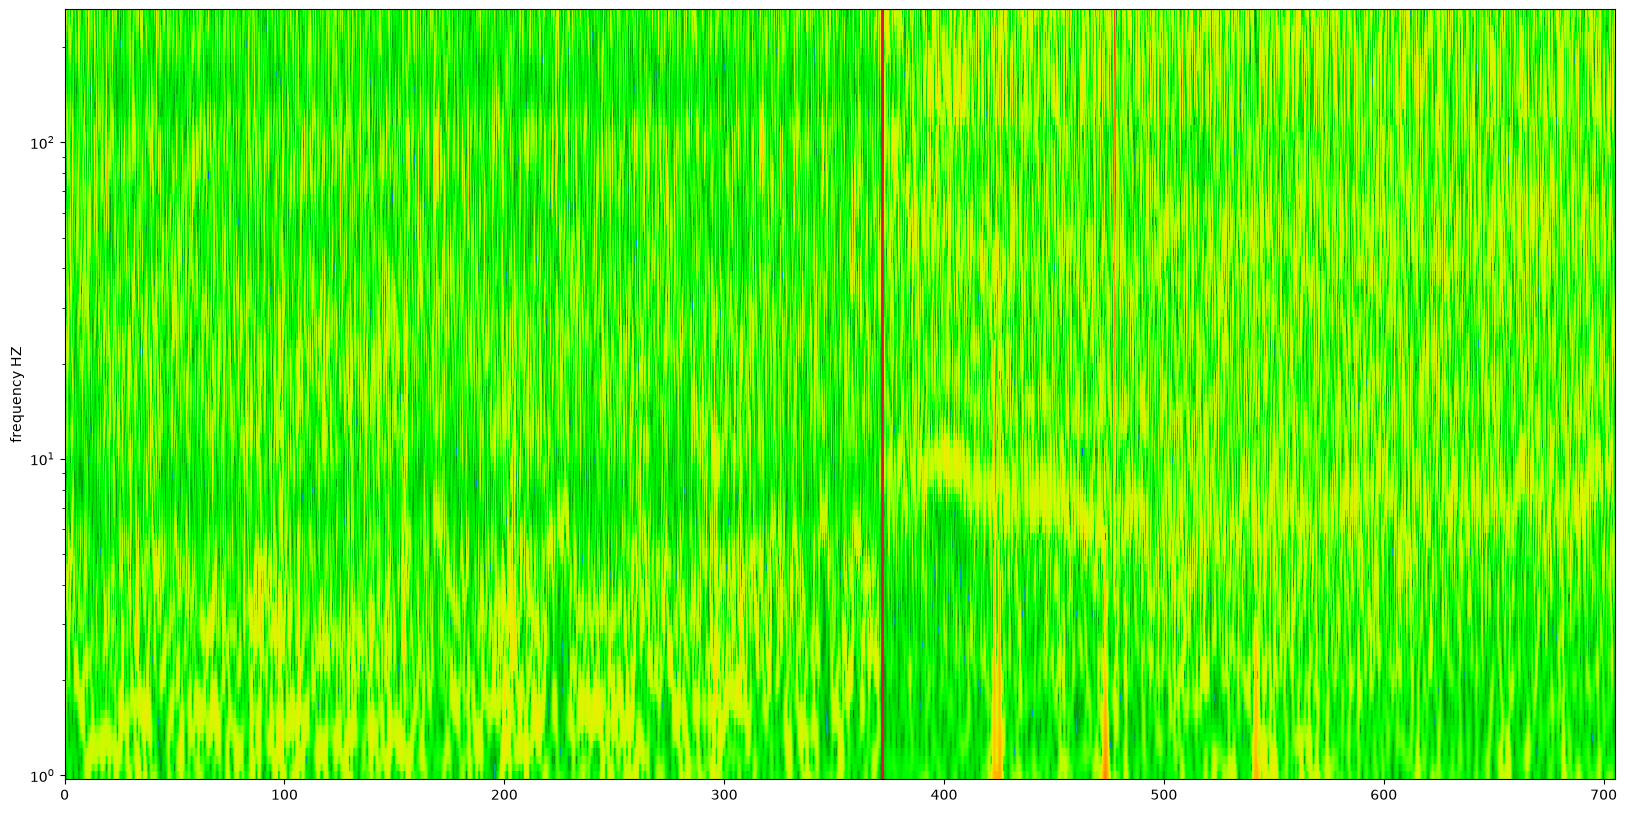

In [6]:
electrode=10

signal = seg.analogsignals[0][:,electrode]
fs = float(seg.analogsignals[0].sampling_rate)
frequencies=np.logspace(0,8,num=100,base=2)*pq.Hz


utils.plot_cwt_spectogram(signal,frequencies)

We see multiple narrowbands in the CWT, so we want to compare how the spiking activity relates to this different narrowbands. And this is why we are obtaing information about phase and amplitude.

In [15]:
signals_filt = elephant.signal_processing.butter(signals, highpass_frequency=130*pq.Hz, lowpass_frequency=180*pq.Hz, filter_function="sosfiltfilt")

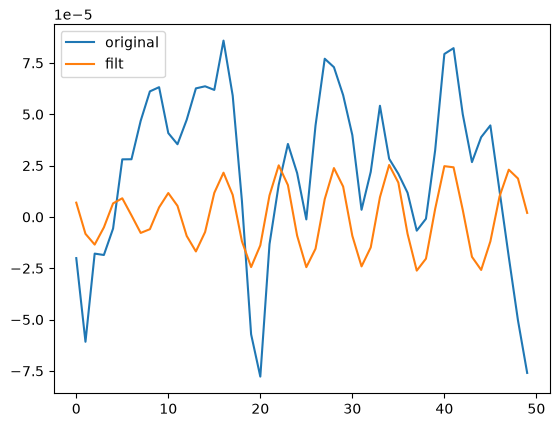

In [21]:
plt.plot(signals[400:450, 0], label="original")
plt.plot(signals_filt[400:450, 0], label="filt")
plt.legend()
plt.show()

We see in the wavelet naroowband activity, so we proceed to use that and focus on the wavelt transformation.

In [25]:
signals_wavelets = elephant.signal_processing.wavelet_transform(signals, frequency=[150*pq.Hz], sampling_frequency=fs)

In [32]:
signals_wavelets.shape

(705000, 64, 1)

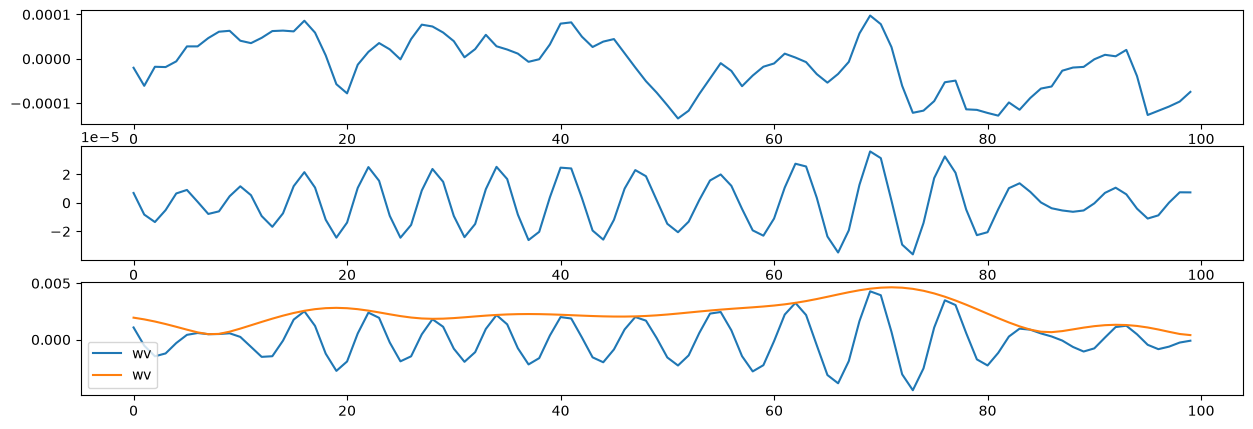

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(15, 5))
axes[0].plot(signals[400:500, 0], label="original")
axes[1].plot(signals_filt[400:500, 0], label="filt")
axes[2].plot(signals_wavelets[400:500, 0], label="wv")
axes[2].plot(np.abs(signals_wavelets[400:500, 0]), label="wv")
plt.legend()
plt.show()

How wavelet signals looks across channel?

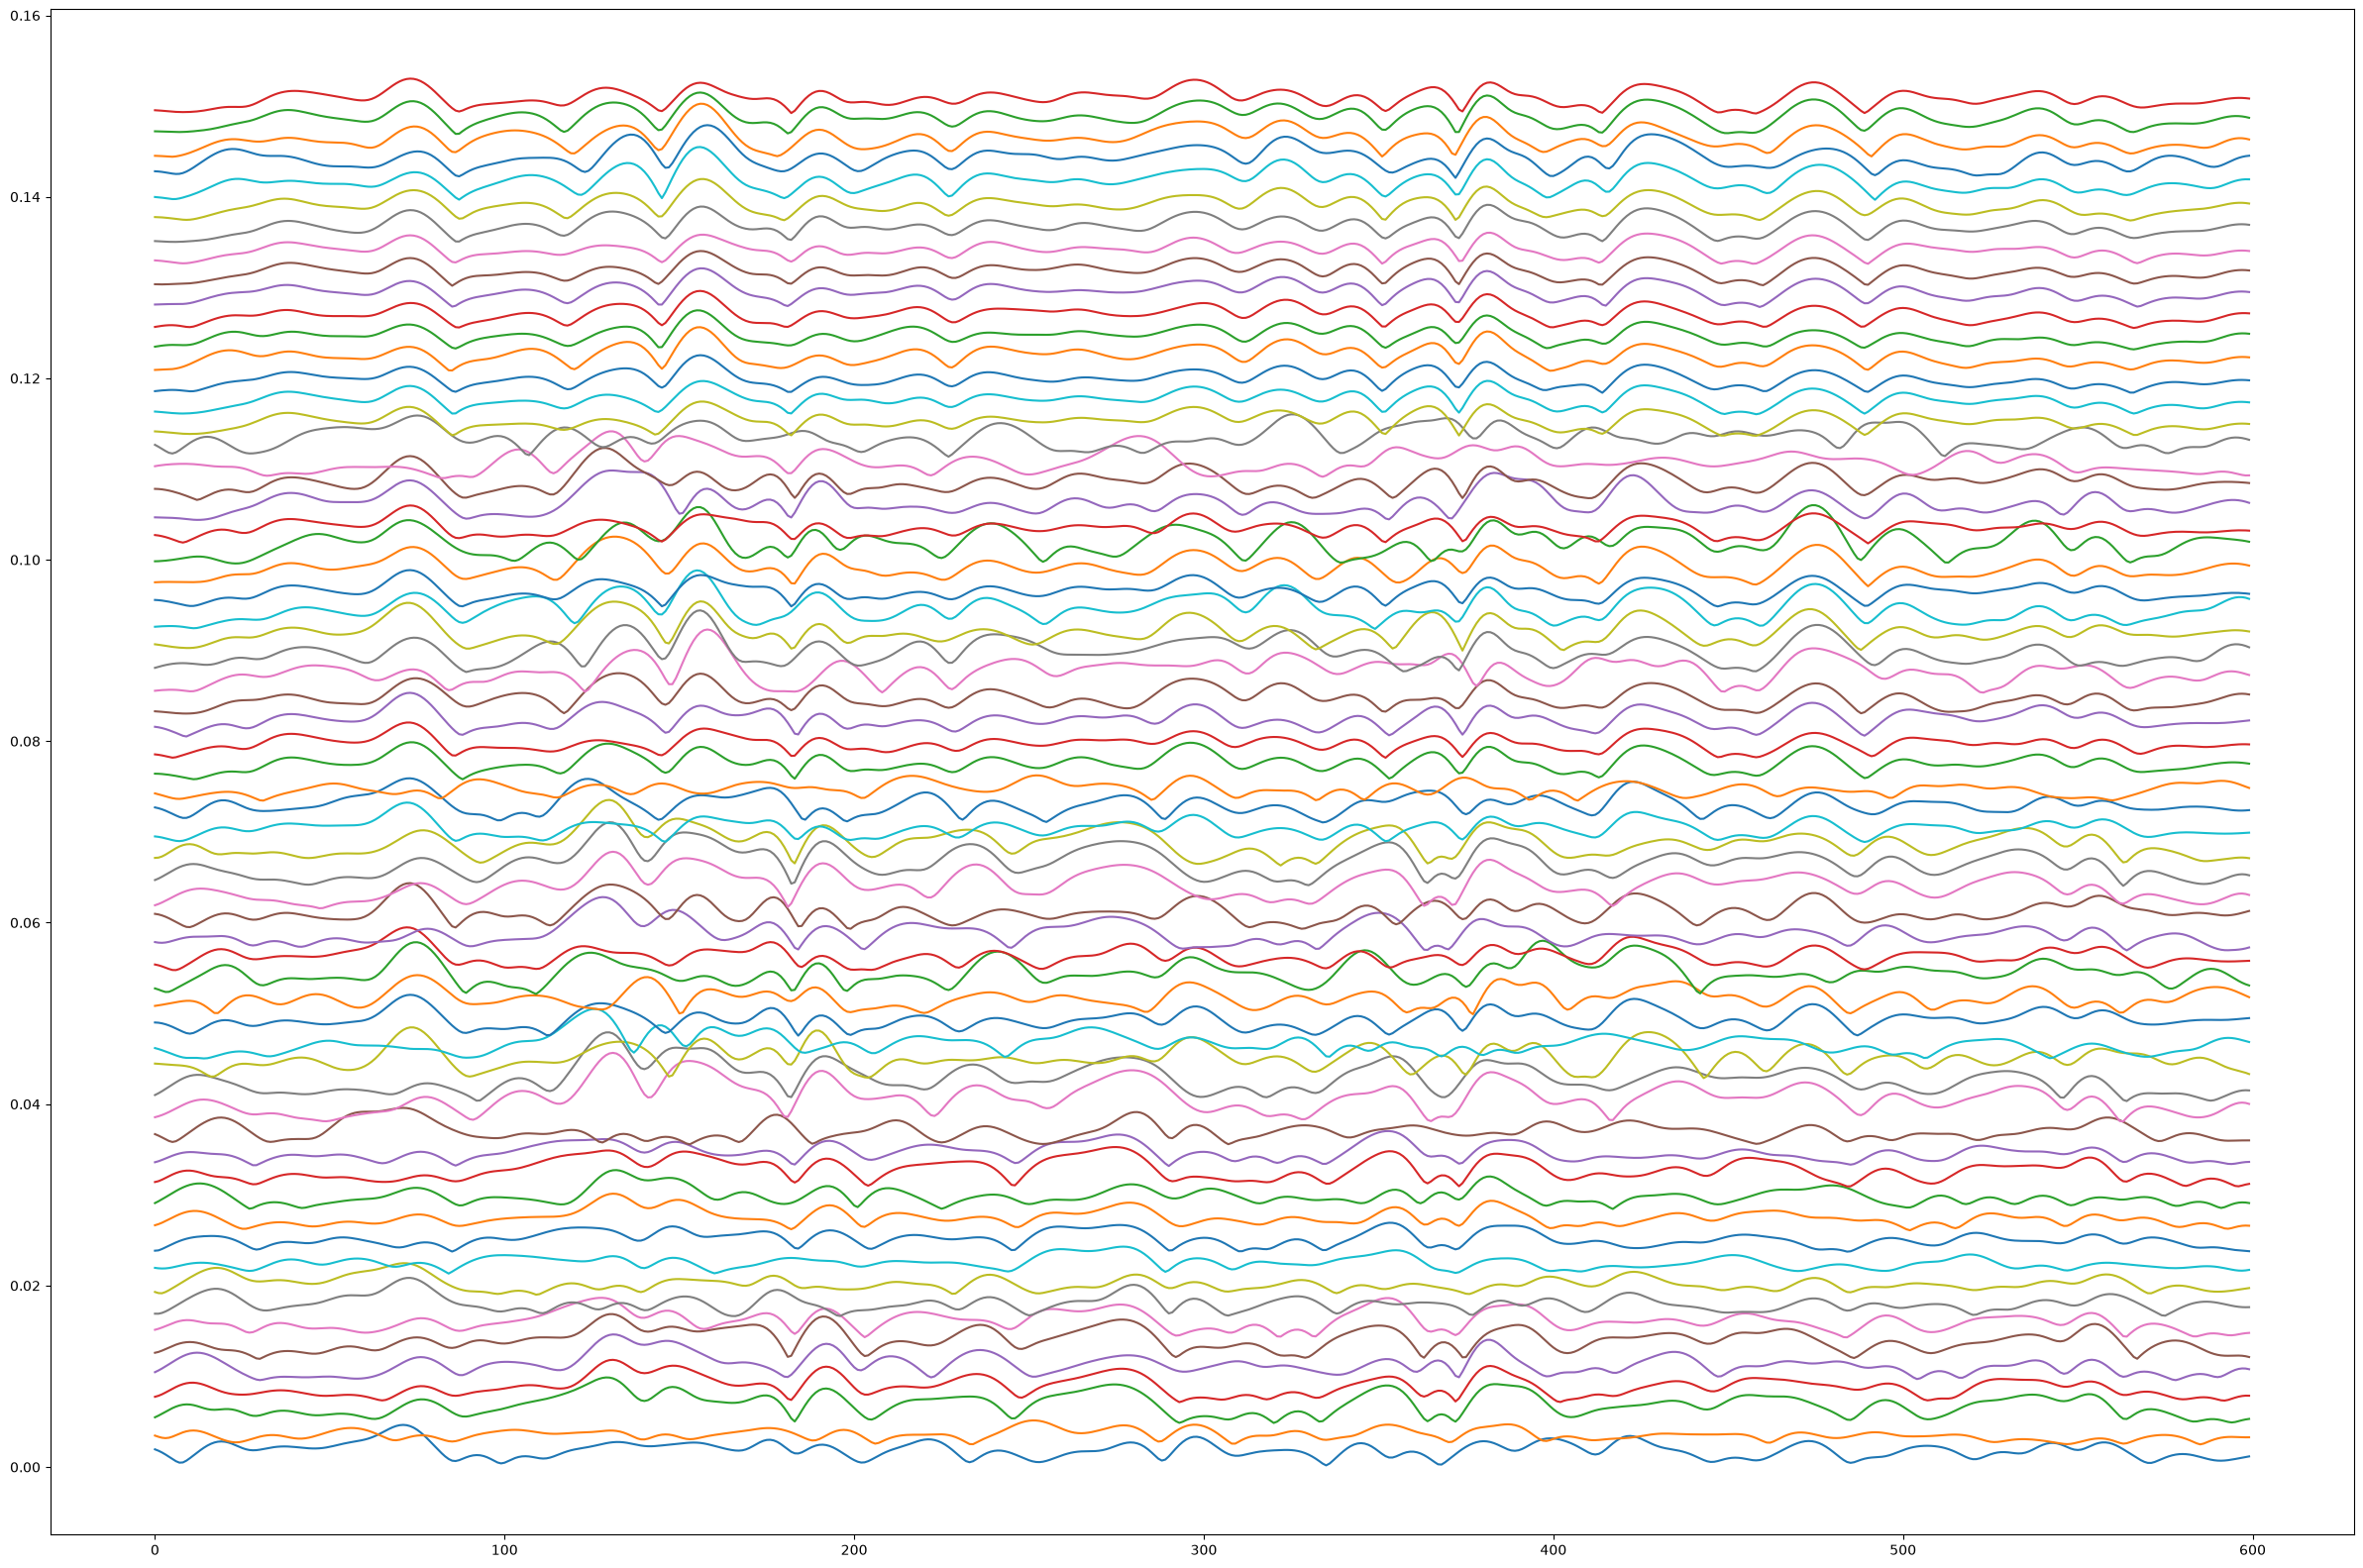

In [37]:
max_val = np.median(np.abs(signals_wavelets))

fig, axes = plt.subplots(figsize=(30, 20))
for i in range(signals_wavelets.shape[1]):
    axes.plot(np.abs(signals_wavelets[400:1000, i])+max_val*i)
plt.show()

In [43]:
signals_wavelets.shape

(705000, 64, 1)

In [48]:
signals.shape

(705000, 64)

In [7]:
eigvals, eigvecs, wavelet_real_signals = utils.process_lfp_pca(signals, frequency=150*pq.Hz)
PR = eigvals.sum()**2 / np.sum(eigvals**2)
print(f"{eigvals.size} eigenvalues, PR = {PR:.2f}")

proj = wavelet_real_signals.T @ eigvecs[:, :3]               # (n_timebins, 3)

(64, 705000)
64 eigenvalues, PR = 1.65
